In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### <font color='orange'> *The Function*
<font color='orange'>
$$ p(x) = 0.164\exp{\left(-\frac{(x-10)^4}{2\cdot 8^2}\right)} $$
</font>

#### Part 1: Drawing 1000 samples via rejection sampling

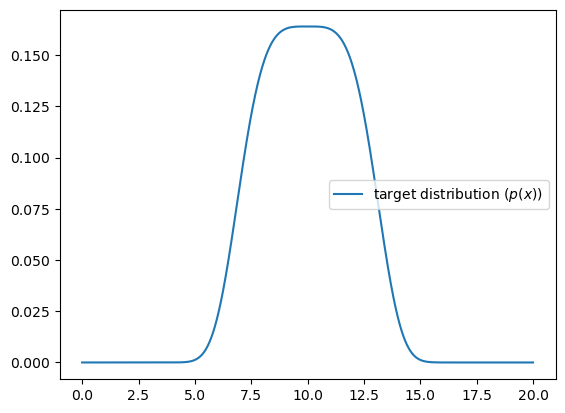

In [19]:
def p(x):
    '''The target distribution to draw samples from'''
    return 0.164*np.exp(-(x-10)**4 / 128)

def g(x):
    '''A distribution we can draw samples from'''
    return np.ones_like(x)

xmin=0
xmax=20
x = np.linspace(xmin,xmax,1000)

plt.plot(x, p(x), label='target distribution ($p(x)$)')
plt.legend()
plt.show()

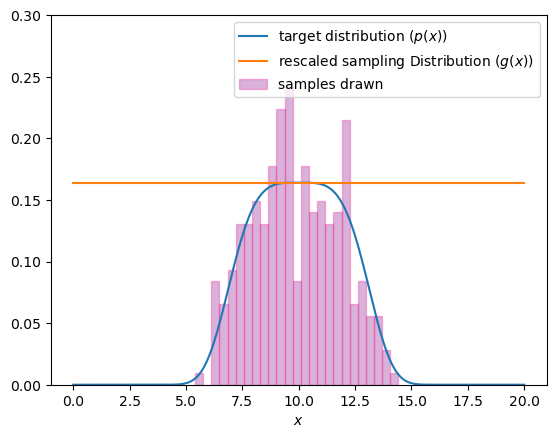

In [44]:
k = max(p(x) / g(x))
n = 1000
def rejection_sampling(n):
    samples = []

    for i in range(n):
        z = np.random.uniform(xmin, xmax)
        u = np.random.uniform(0, k*g(z))

        if u <= p(z):
            samples.append(z)

    return np.array(samples)

s = rejection_sampling(n=1000)
plt.plot(x, p(x), label='target distribution ($p(x)$)')
plt.plot(x, k*g(x), label='rescaled sampling Distribution ($g(x)$)')
plt.hist(s, bins=25, alpha=0.3, color='purple', density=True, edgecolor='deeppink', lw=1, label='samples drawn')

plt.ylim(0, .3)
plt.legend()
plt.xlabel('$x$');

### Part 2: Using Importance Sampling to estimate $\langle x \rangle$

In [45]:
# MEAN FO THE SAMPLES DRAWN IN PART 1
print(f'Mean of the Samples Drawn in Part 1: {np.mean(s)}')

Mean of the Samples Drawn in Part 1: 9.856362304848506


In [51]:
X_g = stats.distributions.norm(loc=10,scale=3)
S = 10000
x_gs = X_g.rvs(S)
ws = p(x_gs) / X_g.pdf(x_gs)
E_x = np.sum(x_gs * ws) / np.sum(ws)
print(f'Extimated expectation value of x: {E_x}')

Extimated expectation value of x: 9.974405889718792


In [58]:
diff = np.abs((np.mean(s) - E_x)/np.mean(s))
print(f'Percent Difference: {diff * 100} %')

Percent Difference: 1.1976384513809732 %


### Part 3: Using Importance Sampling to estimate $x^2$

In [74]:
E_x = np.sum(x_gs ** 2 * ws)/np.sum(ws)
print(f'Extimated expectation value of x^2: {E_x}')

Extimated expectation value of x^2: 103.32280745800489


### Part 4 Grad Student Special: Using Weights to get target distribution

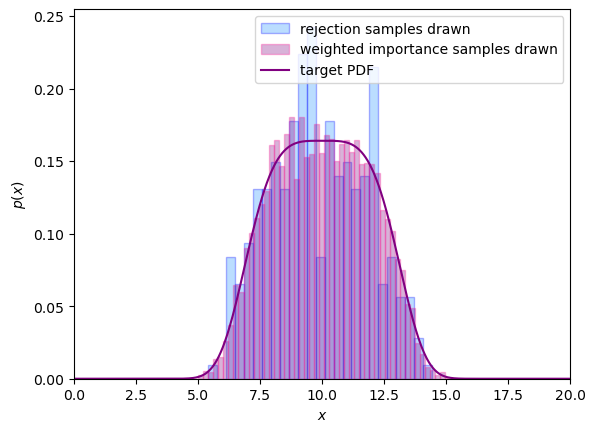

In [72]:
w_max = np.max(ws)
sel = np.random.uniform(0, w_max, S) < ws
plt.hist(s, bins=25, alpha=0.3, color='dodgerblue', density=True, edgecolor='blue', lw=1, label='rejection samples drawn')
plt.hist(x_gs[sel], bins=50, density=True, color='purple', alpha=0.3, edgecolor='deeppink', lw=1, label='weighted importance samples drawn');
plt.plot(x, p(x), color='purple', label='target PDF')

# plt.plot(x, X_g, color='dodgerblue', label='importance sampling distribution')
plt.legend()
plt.xlim(0, 20)
plt.xlabel('$x$')
plt.ylabel('$p(x)$');